**Project Details**

This project aims to predict heart failure outcomes using various machine learning algorithms. A comprehensive EDA was performed to understand the data and relationships between features.

Multiple classification models were trained and evaluated and performance was assessed using accuracy, confusion matrix, precision, recall and f1 score.

Logistic regression was identified as suitable and best performing model and feature importance analysis was coducted to intrepret the influence of different variables.

This project demonstrates how ML can be appplied to healthcare data to support decision making and risk prediction.

In [33]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
#load the data

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.sample (5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
279,55.0,0,84,1,38,0,451000.0,1.3,136,0,0,246,0
109,45.0,0,292,1,35,0,850000.0,1.3,142,1,1,88,0
125,43.0,1,358,0,50,0,237000.0,1.3,135,0,0,97,0
130,53.0,1,1808,0,60,1,249000.0,0.7,138,1,1,106,0
230,60.0,0,166,0,30,0,62000.0,1.7,127,0,0,207,1


**Data Exploration**

In [3]:
df.shape

(299, 13)

In [5]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

**Notes for categorical data:**

Anaemia : 0 means that the person does not have anaemia, if 1 it does.

Diabetes : 0 means that the person does not have diabetes, if 1 it does.

High_blood_pressure : 0 means that the person does not have high_blood_pressure, if 1 it does.

Smoking : 0 means that the person does not smoke, if 1 it smokes.

Sex : 0 for female, 1 for male.

DEATH_EVENT : 0 means heart failure is not the cause of the death, if 1 it is.

In [15]:
pd.set_option('display.max_rows', 300)
df.isna().sum()


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


Note :
we can see that there is no missing data in our dataset

In [41]:
"""
describe() function helps us with the descriptive statistics.
For example we have the minimum age is 40 and the maximum is 95 with a mean of 60.834,
for the same variable, we have the median is 60, standard deviation is 11.895 ...
"""
continuos_data = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]
df[continuos_data].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000


In [35]:

# Categorical summary
categorical_data = ['anaemia','diabetes','high_blood_pressure','sex','smoking']

for col in categorical_data:
    print(f"{col} distribution:")
    print(df[col].value_counts(normalize=True))

anaemia distribution:
anaemia
0    0.568562
1    0.431438
Name: proportion, dtype: float64
diabetes distribution:
diabetes
0    0.58194
1    0.41806
Name: proportion, dtype: float64
high_blood_pressure distribution:
high_blood_pressure
0    0.648829
1    0.351171
Name: proportion, dtype: float64
sex distribution:
sex
1    0.648829
0    0.351171
Name: proportion, dtype: float64
smoking distribution:
smoking
0    0.67893
1    0.32107
Name: proportion, dtype: float64


In [24]:
df.groupby("DEATH_EVENT").count()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
DEATH_EVENT,,,,,,,,,,,,
0,203,203,203,203,203,203,203,203,203,203,203,203
1,96,96,96,96,96,96,96,96,96,96,96,96


Note:
Since our result is DEATH_EVENT, we grouped our dataset by DEATH_EVENT and we can see that our dataset is unbalanced

**Visualizing the unbalanced data with a scatter plot, the colors will depend on DEATH_EVENT (0 or 1)**

In [25]:
age = df[["age"]]
platelets = df[["platelets"]]

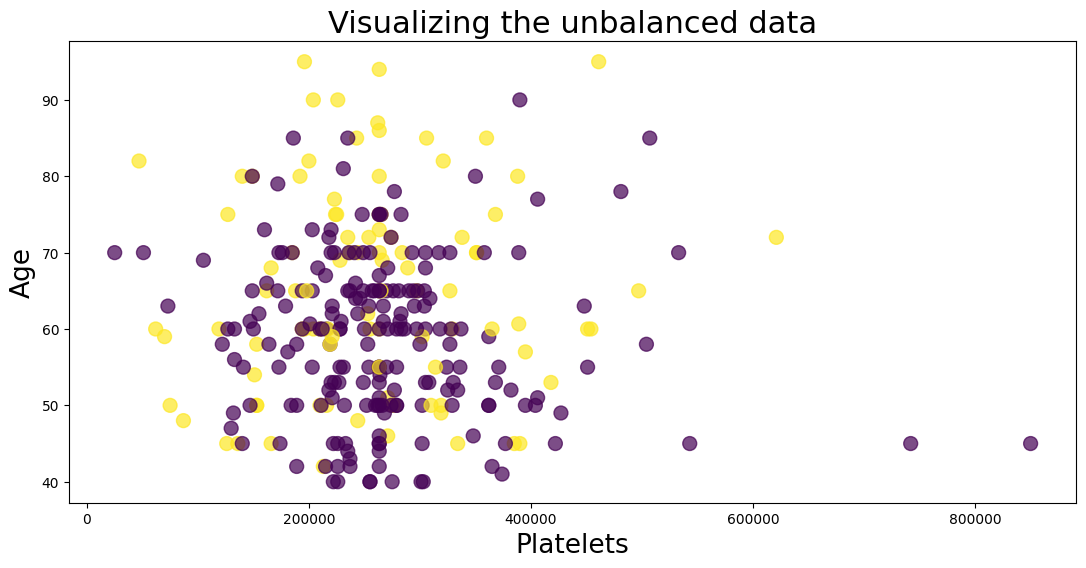

In [32]:
plt.figure(figsize=(13,6))
plt.scatter(platelets, age, c = df["DEATH_EVENT"], s=100, alpha=0.7)
plt.xlabel("Platelets", fontsize=19)
plt.ylabel("Age",fontsize=19)
plt.title("Visualizing the unbalanced data", fontsize=22)
plt.show()

Note:
We can see that we do have more circles in purple than in yellow

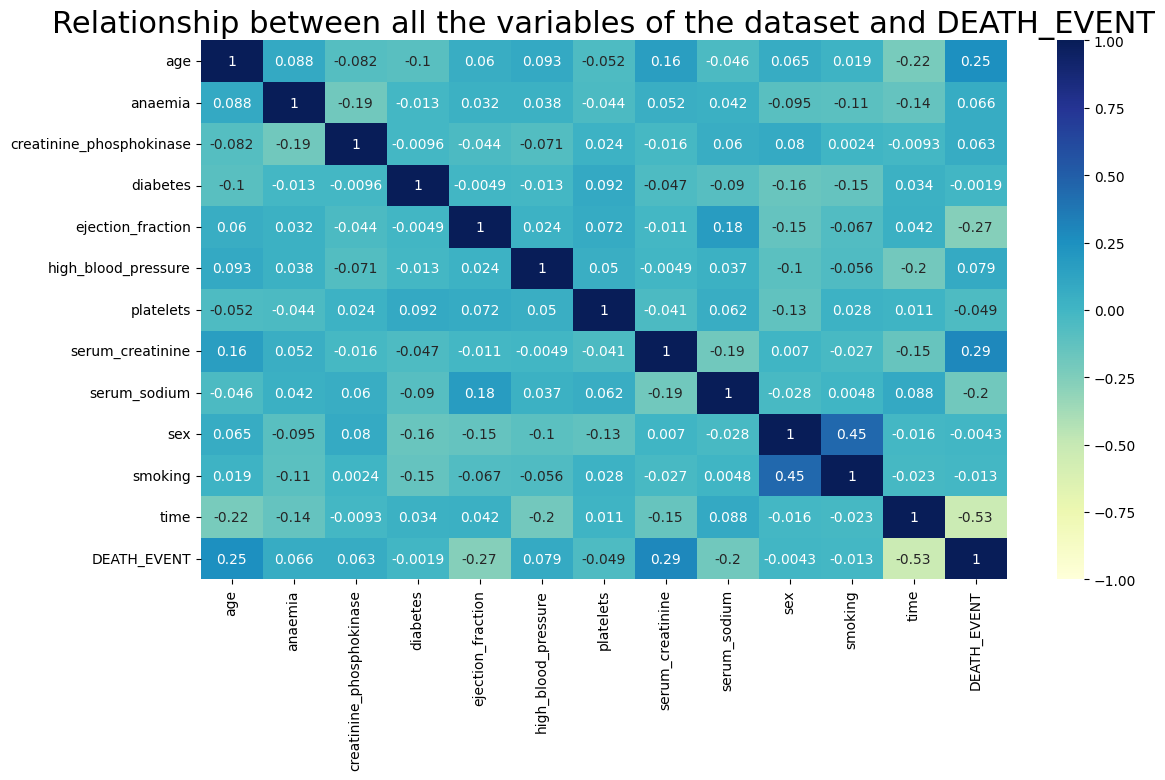

In [34]:
plt.figure(figsize=(13,7))
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap="YlGnBu", annot=True)
plt.title("Relationship between all the variables of the dataset and DEATH_EVENT", fontsize = 22)
plt.show()

Note:
We notice that there is a positive correlation between DEATH_EVENT and serum creatinine and age. We have also a negative correlation between DEATH_EVENT and time, ejection fraction and serum sodium a little bit.

**2. Data visualization:**

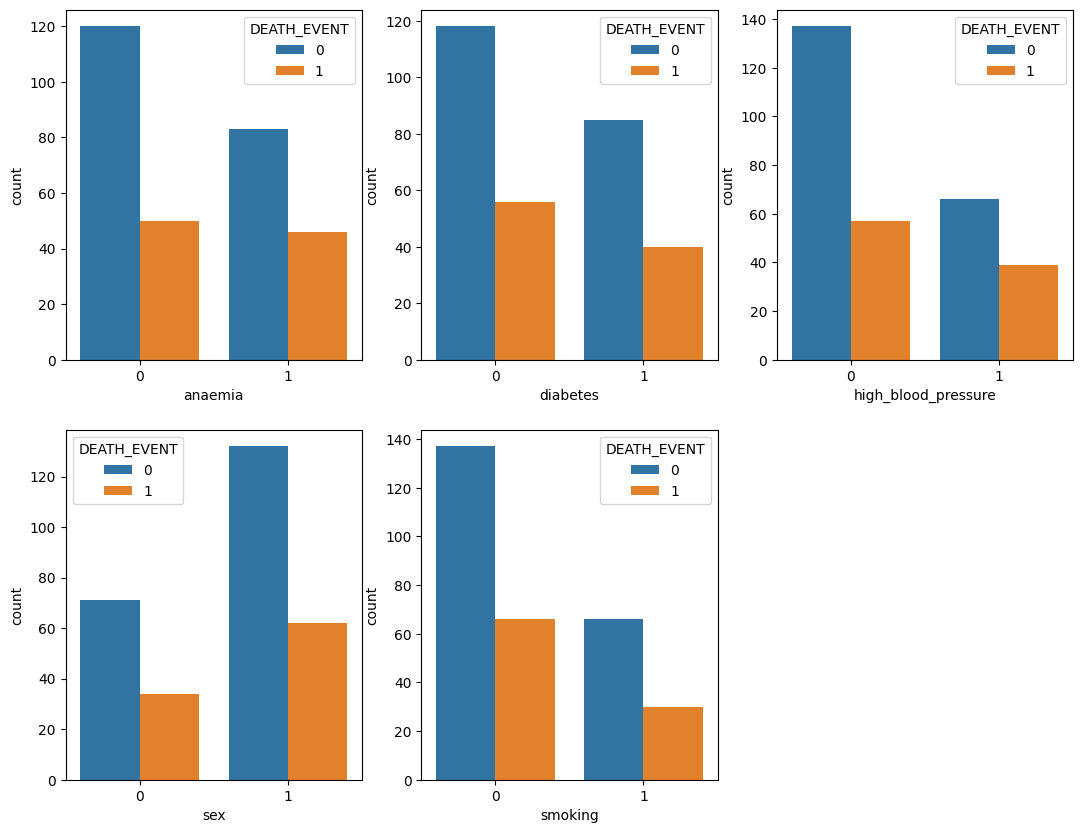

In [36]:
# Plotting the impact of categorical variables on DEATH_EVENT

plt.figure(figsize=(13,10))
for i,cat in enumerate(categorical_data):
    plt.subplot(2,3,i+1)
    sns.countplot(data = df, x= cat, hue = "DEATH_EVENT")
plt.show()

<Axes: xlabel='diabetes', ylabel='count'>

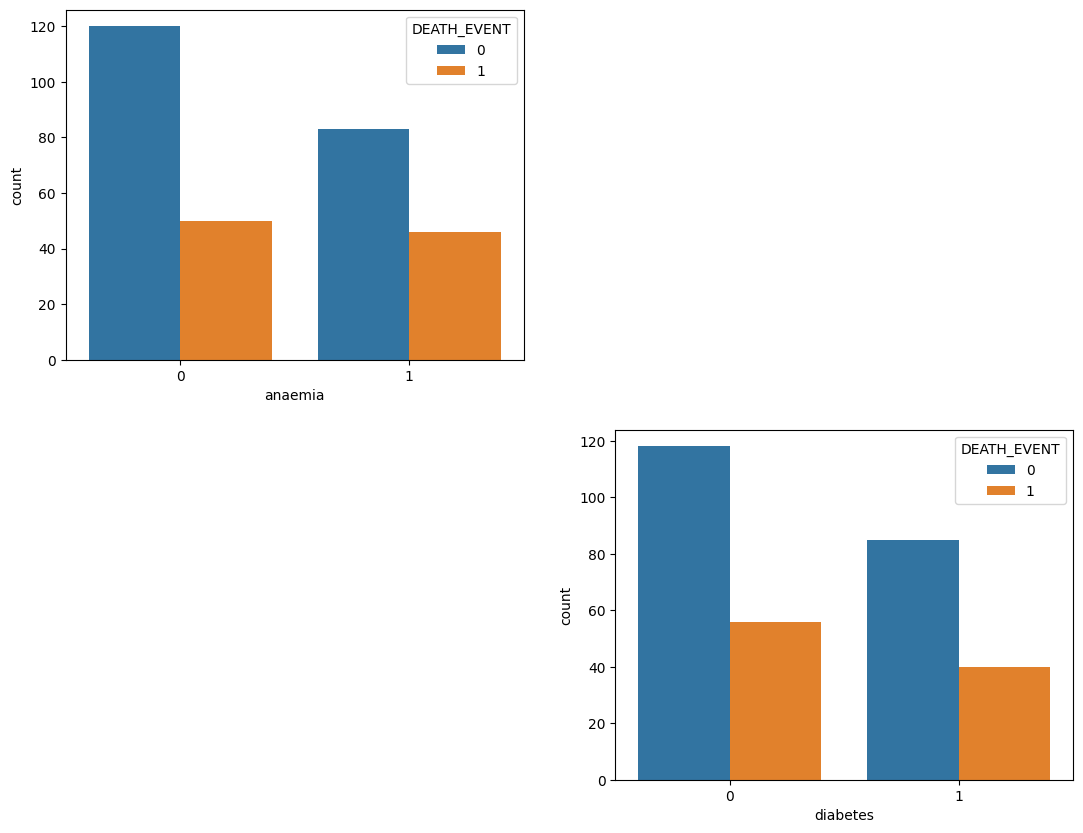

In [38]:
plt.figure(figsize=(13,10))
plt.subplot(2,2,1)
sns.countplot(data = df, x= 'anaemia', hue = "DEATH_EVENT")
plt.subplot(2,2,4)
sns.countplot(data = df, x= 'diabetes', hue = "DEATH_EVENT")

In [39]:
for i,cat in enumerate(categorical_data):
    print(i, cat)

0 anaemia
1 diabetes
2 high_blood_pressure
3 sex
4 smoking


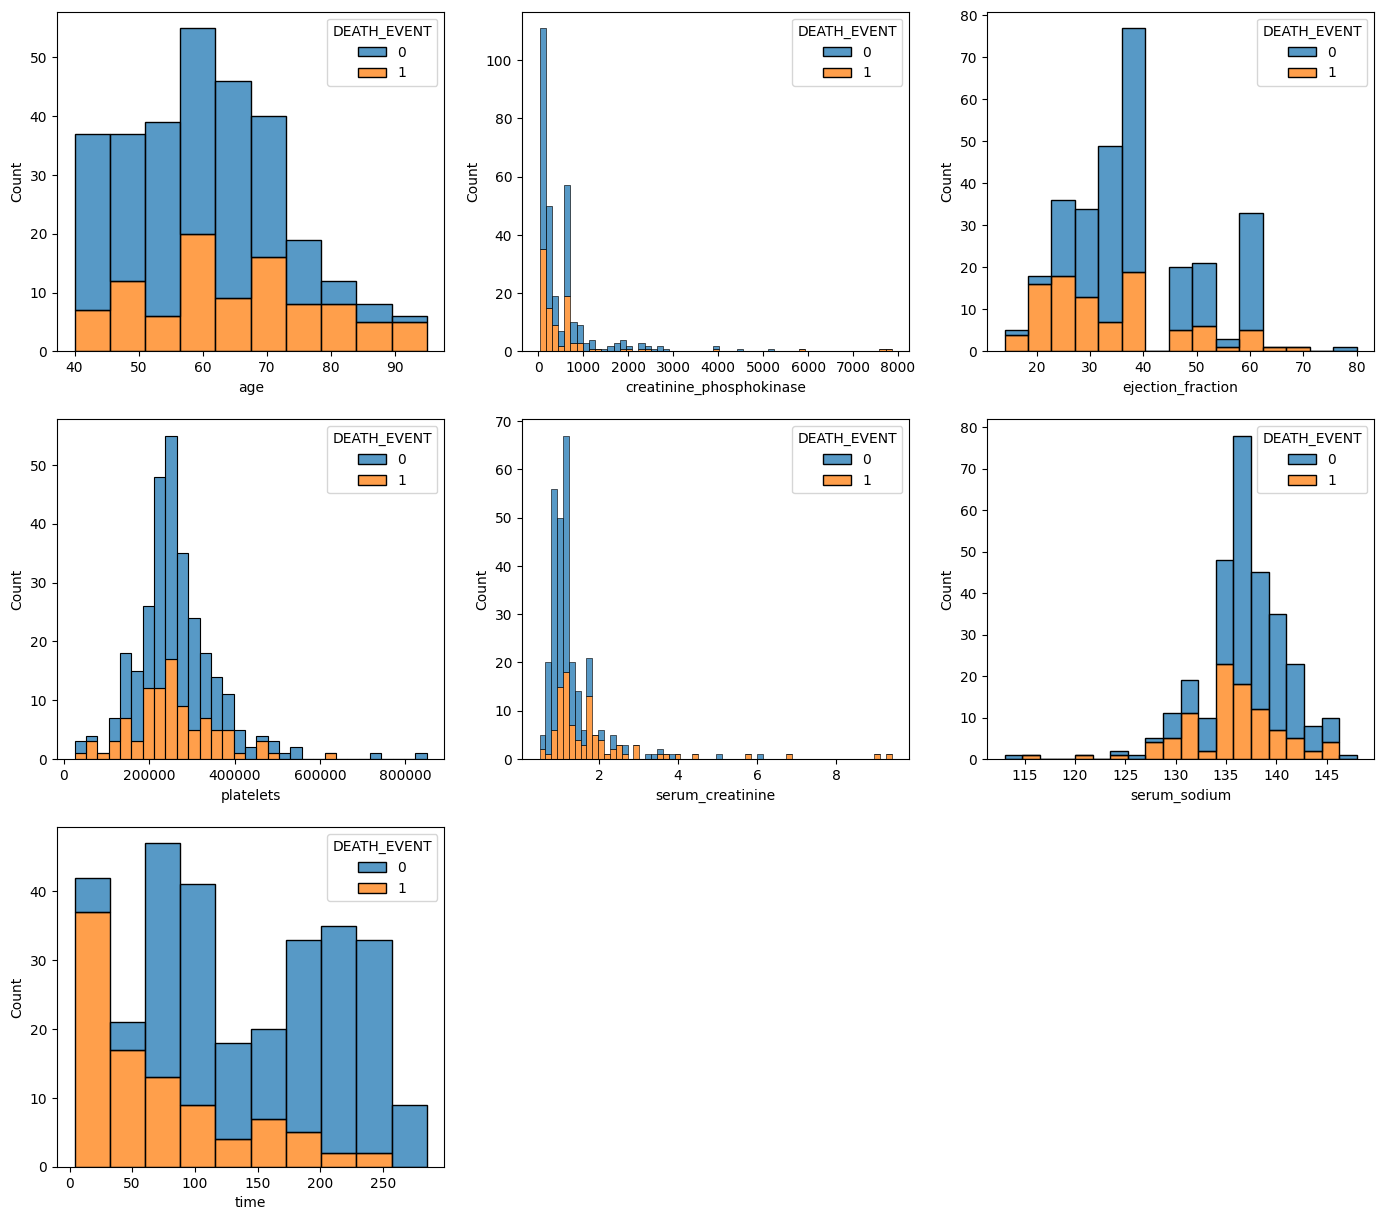

In [42]:
# Plotting the impact of continuous variables on DEATH_EVENT

plt.figure(figsize=(17,15))
for j,con in enumerate(continuos_data):
    plt.subplot(3,3,j+1)
    sns.histplot(data = df, x= con, hue = "DEATH_EVENT", multiple="stack")
plt.show()

In [44]:
for i,cat in enumerate(continuos_data):
    print(i, cat)

0 age
1 creatinine_phosphokinase
2 ejection_fraction
3 platelets
4 serum_creatinine
5 serum_sodium
6 time


<Axes: xlabel='age', ylabel='Count'>

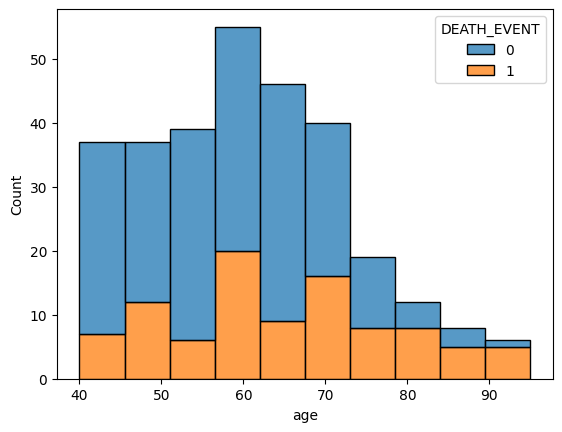

In [45]:
sns.histplot(data = df, x= 'age', hue = "DEATH_EVENT", multiple="stack")

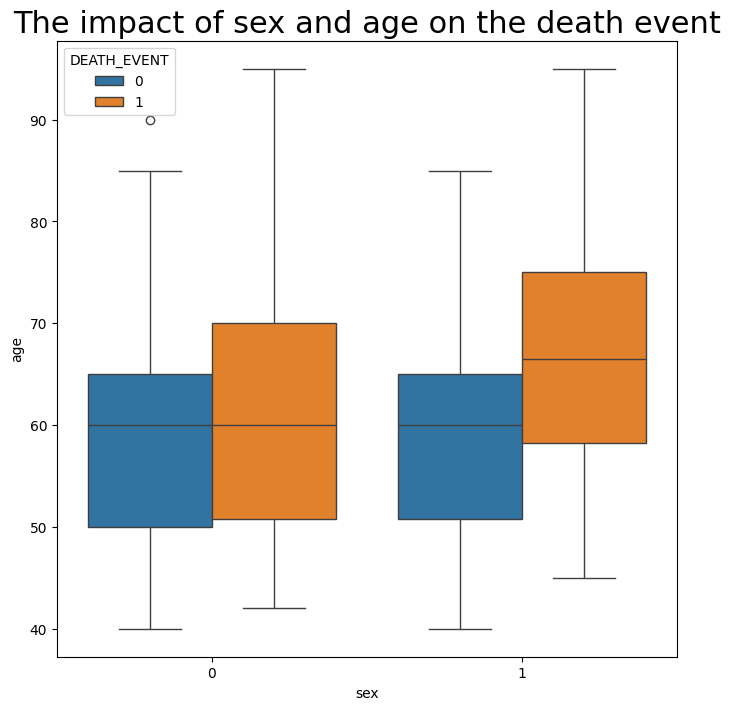

In [47]:
plt.figure(figsize=(8,8))
sns.boxplot(data=df, x="sex", y="age", hue="DEATH_EVENT")
plt.title("The impact of sex and age on the death event", fontsize=22)
plt.show()

In [64]:
def plot_pie(df, col):
    counts = df.groupby([col, 'DEATH_EVENT']).size().reset_index(name='count')

    labels = []
    values = []

    for _, row in counts.iterrows():
        labels.append(f"{col}={row[col]}, death={row['DEATH_EVENT']}")
        values.append(row['count'])

    plt.figure(figsize=(6,6))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)

    # Donut effect
    centre = plt.Circle((0,0), 0.7, fc='white')
    plt.gca().add_artist(centre)

    plt.title(f"{col} vs Death Event")
    plt.show()

The pie charts show the distribution of survival and death across different categorical variables such as smoking, sex, diabetes, anaemia, and high blood pressure.

It can be observed that risk-related groups (e.g., smokers, patients with high blood pressure or diabetes) tend to have a relatively higher proportion of death events, while non-risk groups generally show higher survival.

These patterns suggest that medical conditions and lifestyle factors may influence heart failure outcomes.


Limitations of Pie Charts:

Pie charts provide a general view of proportions but have several limitations:

They do not show precise comparisons between groups
They represent overall proportions, not category-specific survival rates
Multiple slices can make interpretation unclear

Therefore, bar plots and summary tables are used alongside pie charts for more accurate analysis.

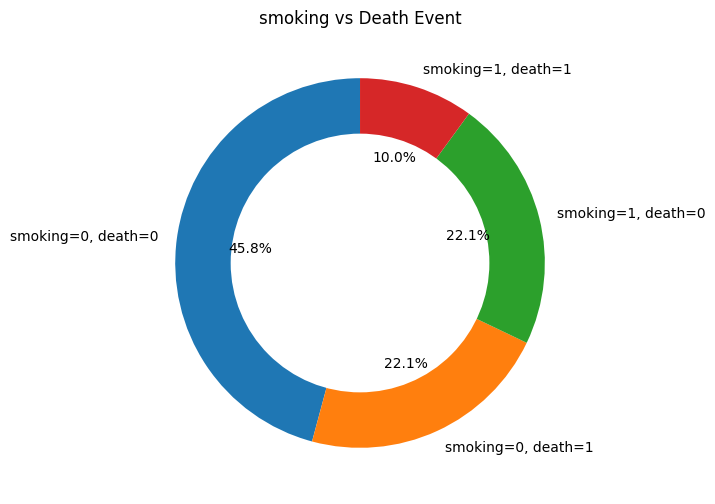

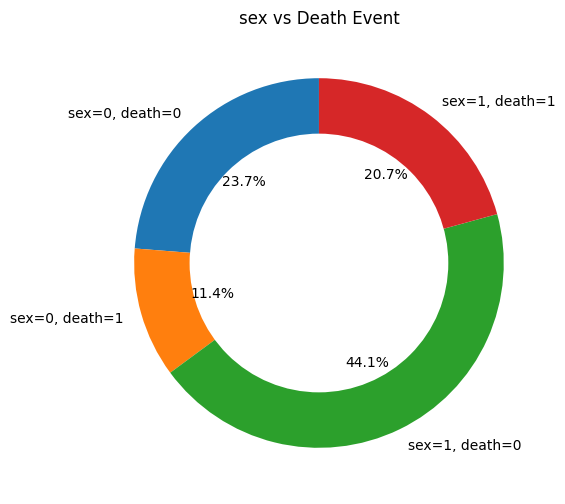

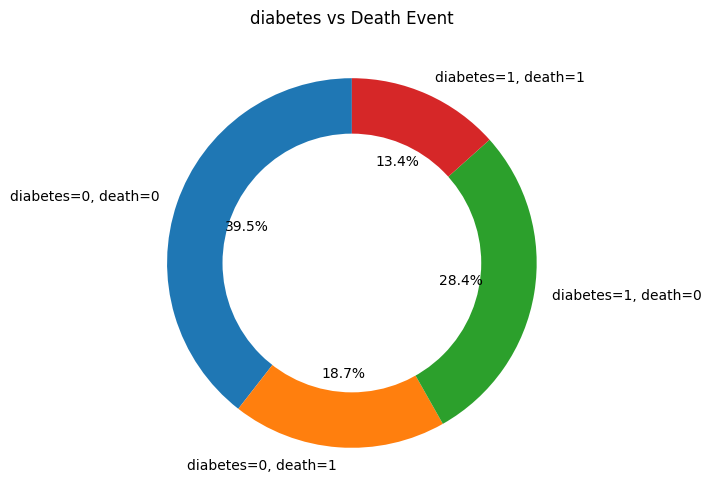

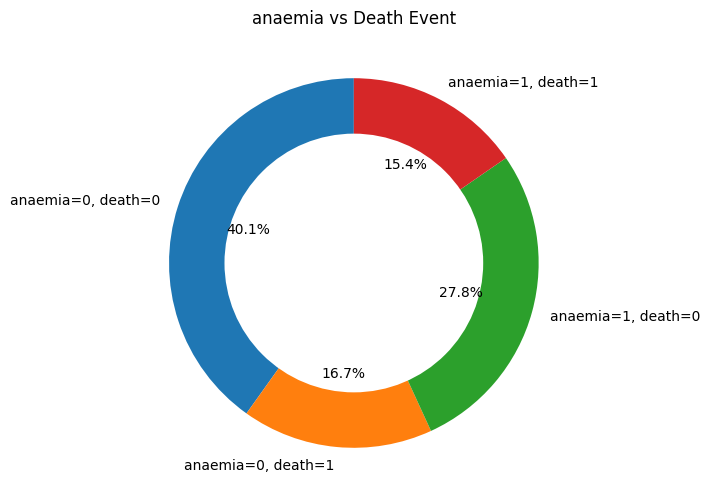

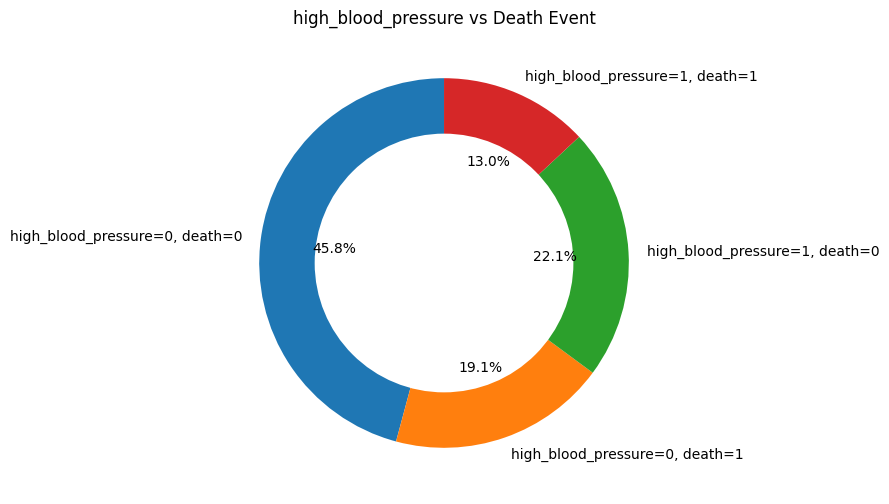

In [65]:
categorical_data = ['smoking','sex','diabetes','anaemia','high_blood_pressure']

for col in categorical_data:
    plot_pie(df, col)

In [59]:
def survival_barplot(df, column):
    plt.figure(figsize=(5,3))
    sns.countplot(x=column, hue='DEATH_EVENT', data=df)
    plt.title(f"{column} vs Death Event")
    plt.show()

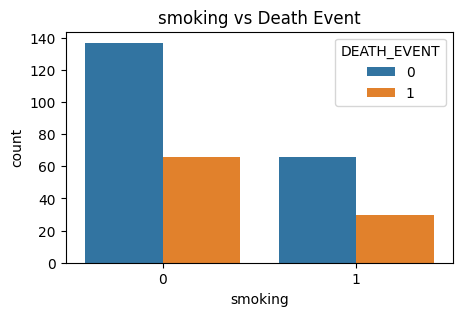

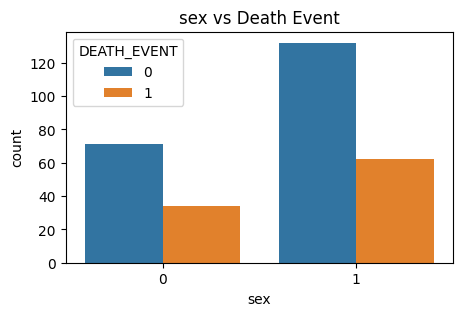

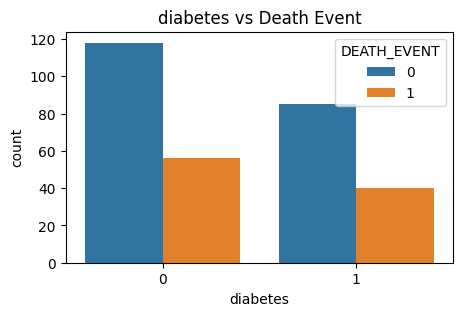

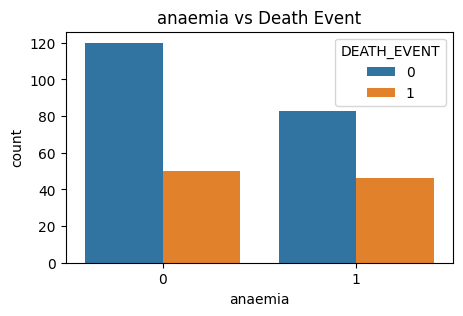

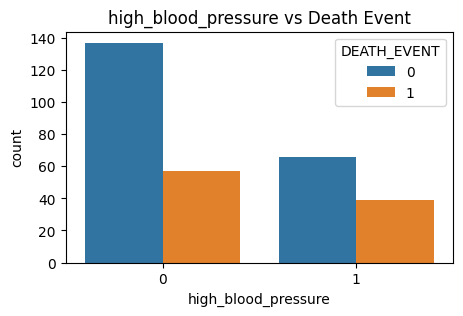

In [60]:
survival_barplot(df, 'smoking')
survival_barplot(df, 'sex')
survival_barplot(df, 'diabetes')
survival_barplot(df, 'anaemia')
survival_barplot(df, 'high_blood_pressure')



The bar plots compare the distribution of survival and death events across different categorical variables such as smoking, sex, diabetes, anaemia, and high blood pressure.

From the plots, it is observed that:

Certain groups, including smokers and patients with high blood pressure or diabetes, show higher counts of death events compared to their counterparts.
Non-risk groups generally have higher survival counts.
Gender-based differences also indicate variation in outcomes.

Overall, the bar plots provide clearer and more precise comparisons between categories, reinforcing the relationship between these factors and patient survival

In [ ]:
def survival_summary(df, column):
    """
    Returns a clean summary table showing survival vs death counts and percentages
    for a given categorical feature.
    """

    summary = pd.crosstab(df[column], df['DEATH_EVENT'])

    # Rename columns for clarity
    summary.columns = ['Survived (0)', 'Died (1)']

    # Add percentage columns
    summary['Survival Rate (%)'] = (summary['Survived (0)'] / summary.sum(axis=1)) * 100
    summary['Death Rate (%)'] = (summary['Died (1)'] / summary.sum(axis=1)) * 100

    return summary

In [66]:
print("Smoking Summary")
display(survival_summary(df, 'smoking'))

print("Sex Summary")
display(survival_summary(df, 'sex'))

print("Diabetes Summary")
display(survival_summary(df, 'diabetes'))

print("Anaemia Summary")
display(survival_summary(df, 'anaemia'))

print("High Blood Pressure Summary")
display(survival_summary(df, 'high_blood_pressure'))

Smoking Summary


,Survived (0),Died (1),Survival Rate (%),Death Rate (%)
smoking,,,,
0,137,66,67.487685,24.400372
1,66,30,68.750000,18.209408


Sex Summary


,Survived (0),Died (1),Survival Rate (%),Death Rate (%)
sex,,,,
0,71,34,67.619048,19.696552
1,132,62,68.041237,23.660398


Diabetes Summary


,Survived (0),Died (1),Survival Rate (%),Death Rate (%)
diabetes,,,,
0,118,56,67.816092,23.158095
1,85,40,68.000000,20.725389


Anaemia Summary


,Survived (0),Died (1),Survival Rate (%),Death Rate (%)
anaemia,,,,
0,120,50,70.588235,20.782396
1,83,46,64.341085,23.792149


High Blood Pressure Summary


,Survived (0),Died (1),Survival Rate (%),Death Rate (%)
high_blood_pressure,,,,
0,137,57,70.618557,21.540439
1,66,39,62.857143,23.234043



The survival summary tables show that patients with risk factors such as smoking, diabetes, and high blood pressure have higher death rates, while non-risk groups exhibit higher survival, highlighting the impact of these factors on heart failure outcomes.

Unlike visual plots, these tables offer precise numerical insights, allowing for accurate comparison of survival probabilities within each category.


**Data Preprocessing**

In [67]:
# Separate features and target
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

In [69]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Training**

In [71]:
# Import ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [72]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}

In [73]:
results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Store predictions
    results[name] = y_pred

In [74]:
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, y_pred in results.items():
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8000
SVM: 0.7500
KNN: 0.6833
Decision Tree: 0.6500
Naive Bayes: 0.7000
Random Forest: 0.7667


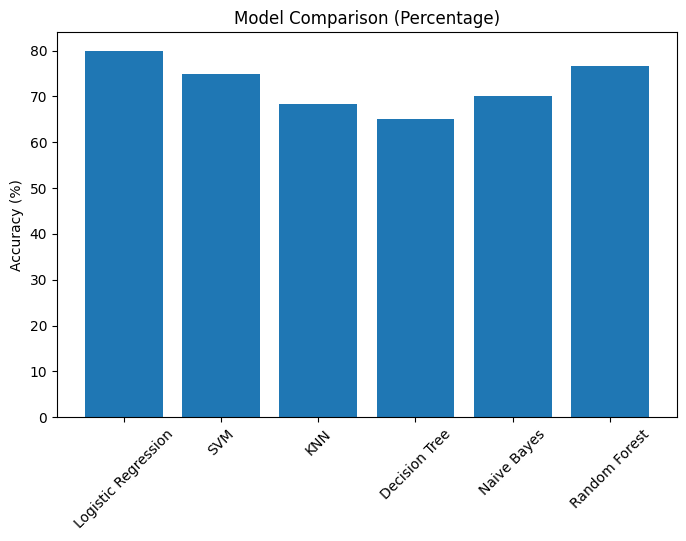

In [77]:
import matplotlib.pyplot as plt

accuracy_percent = {k: v * 100 for k, v in accuracy_results.items()}

plt.figure(figsize=(8,5))
plt.bar(accuracy_percent.keys(), accuracy_percent.values())

plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison (Percentage)")

plt.show()

In [78]:
best_model_name = max(accuracy_results, key=accuracy_results.get)
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [79]:
from sklearn.metrics import confusion_matrix, classification_report
for name, y_pred in results.items():

    print(f"\n===== {name} =====")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====

Confusion Matrix:
[[34  1]
 [11 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60


===== SVM =====

Confusion Matrix:
[[33  2]
 [13 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.86      0.48      0.62        25

    accuracy                           0.75        60
   macro avg       0.79      0.71      0.72        60
weighted avg       0.78      0.75      0.73        60


===== KNN =====

Confusion Matrix:
[[34  1]
 [18  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.97     

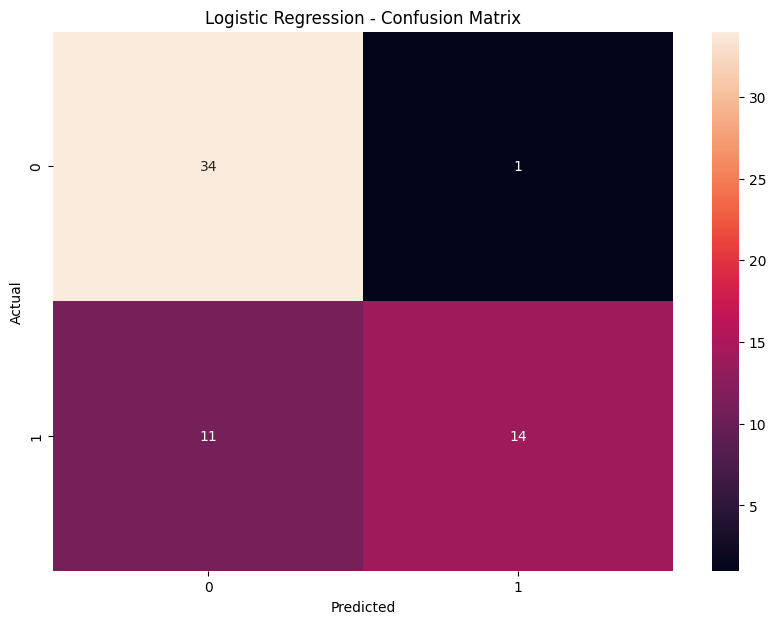

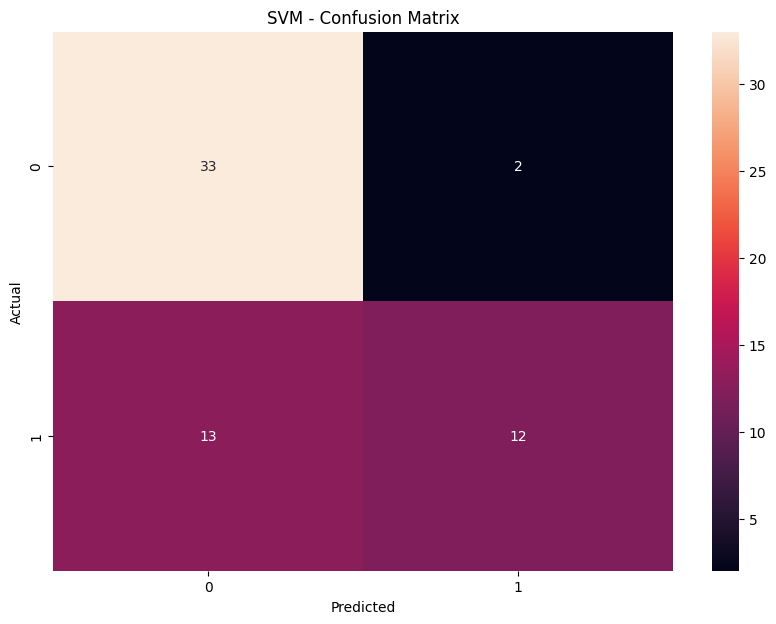

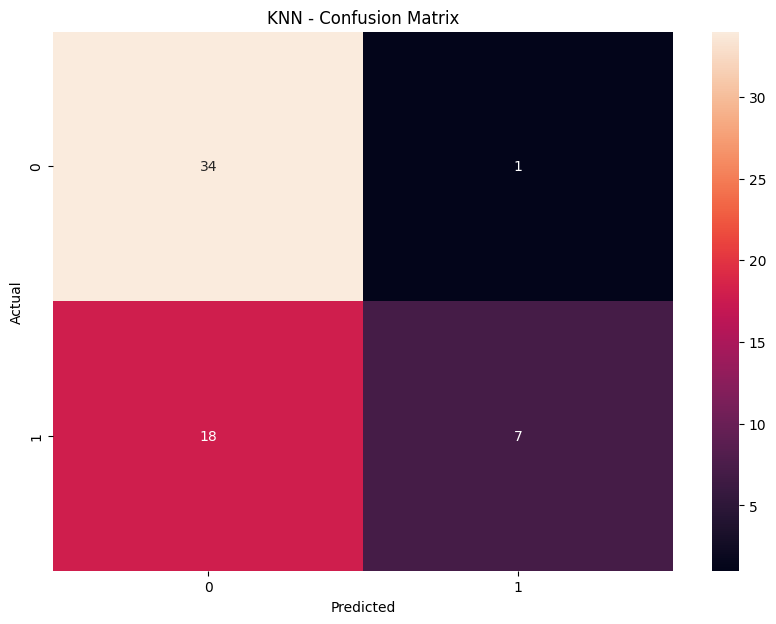

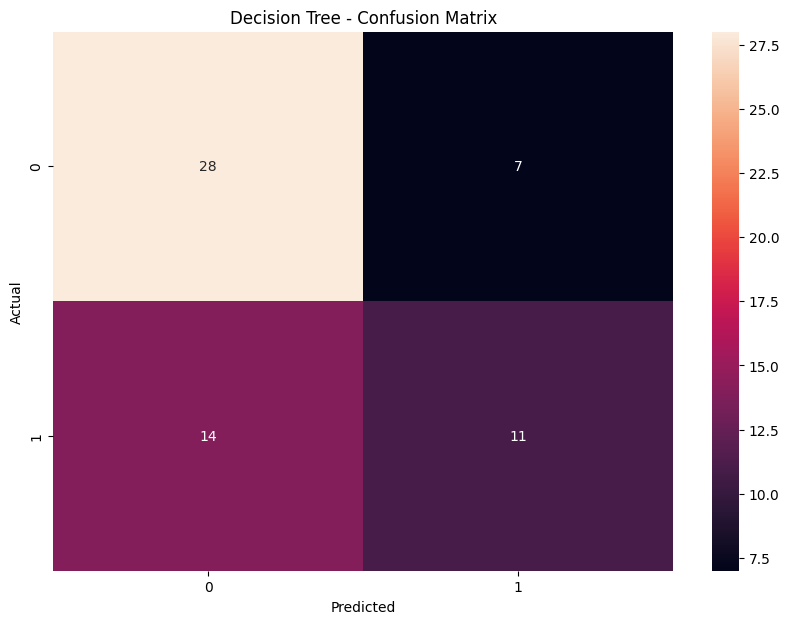

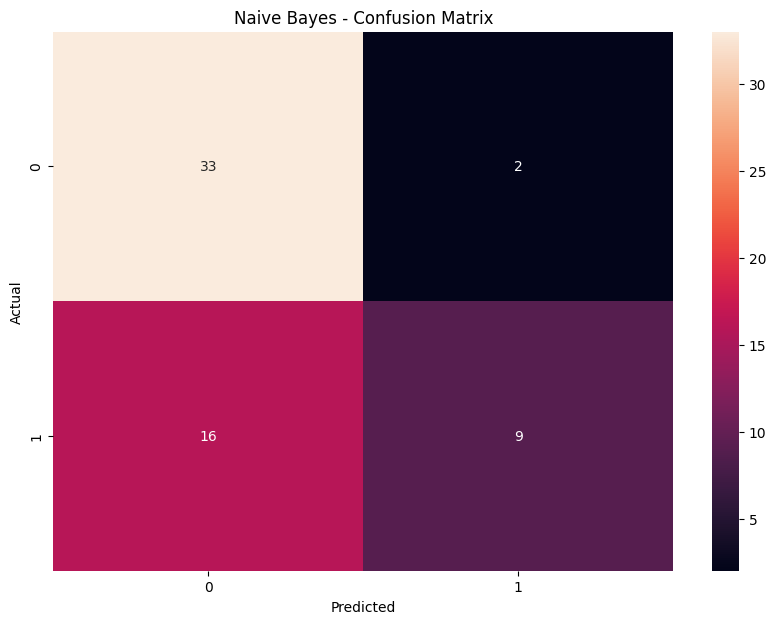

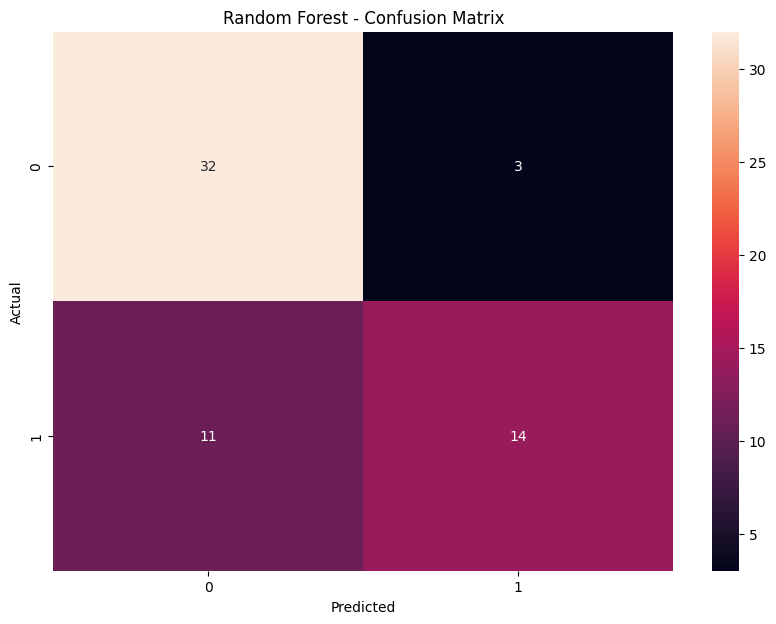

In [81]:
import seaborn as sns

for name, y_pred in results.items():

    plt.figure(figsize=(10,7))
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [83]:
# Running Feature importance for Logistic Regression model

lr_model = models["Logistic Regression"]

In [84]:
coefficients = lr_model.coef_[0]
features = X.columns

In [86]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

coef_df['Importance'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Importance', ascending=False)

coef_df

,Feature,Coefficient,Importance
11,time,-1.651880,1.651880
4,ejection_fraction,-0.876051,0.876051
7,serum_creatinine,0.701778,0.701778
0,age,0.660645,0.660645
9,sex,-0.362421,0.362421
8,serum_sodium,-0.260489,0.260489
6,platelets,-0.170253,0.170253
3,diabetes,0.164116,0.164116
2,creatinine_phosphokinase,0.110553,0.110553
10,smoking,0.071272,0.071272


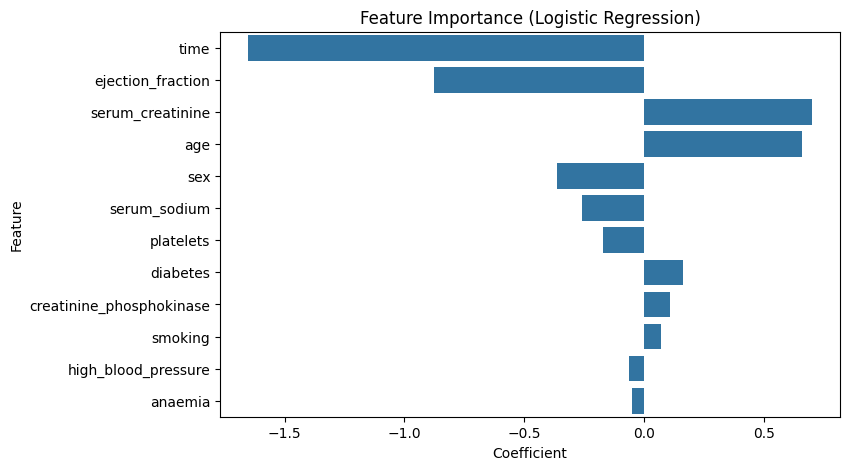

In [87]:
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)

plt.title("Feature Importance (Logistic Regression)")
plt.show()

The feature importance plot shows that time, ejection fraction, and serum creatinine are the most influential predictors.
Time and ejection fraction reduce death risk (negative), while serum creatinine and age increase risk (positive).
Other features have smaller influence, and scaling allows direct comparison of coefficients.